# 02 · Exploratory Analysis — Where is claim revenue being lost?

**Business question:** The payer-relations team wants to know *why* claims are being denied,
*which* providers and plan types drive the problem, and *how much money* is at stake.

Input: `Data/clean/claims_clean.csv` (built by notebook 01). Charts are saved to `Image/`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import viz_style as vs

vs.apply()
ROOT = Path.cwd().parent if Path.cwd().name == "Python" else Path.cwd()
claims = pd.read_csv(ROOT / "Data" / "clean" / "claims_clean.csv",
                     parse_dates=["service_date", "submission_date", "processed_date"],
                     dtype={"cpt_code": str})
providers = pd.read_csv(ROOT / "Data" / "clean" / "providers_clean.csv")
adjudicated = claims[claims["claim_status"] != "Pending"]   # denial rate is measured on decided claims only

## 1. Headline KPIs

In [2]:
kpi = {
    "Total claims":            f"{len(claims):,}",
    "Total billed":            f"${claims['billed_amount'].sum():,.0f}",
    "Total paid":              f"${claims['paid_amount'].sum():,.0f}",
    "Denial rate":             f"{adjudicated['is_denied'].mean():.1%}",
    "Denied billed $ (at risk)": f"${claims.loc[claims['is_denied'] == 1, 'billed_amount'].sum():,.0f}",
    "Avg days to process":     f"{claims['days_to_process'].mean():.1f}",
    "Unique patients":         f"{claims['patient_id'].nunique():,}",
}
pd.Series(kpi, name="value").to_frame()

,value
Total claims,"50,000"
Total billed,"$138,609,693"
Total paid,"$47,571,952"
Denial rate,12.2%
Denied billed $ (at risk),"$19,162,951"
Avg days to process,15.9
Unique patients,"7,946"


## 2. Monthly volume

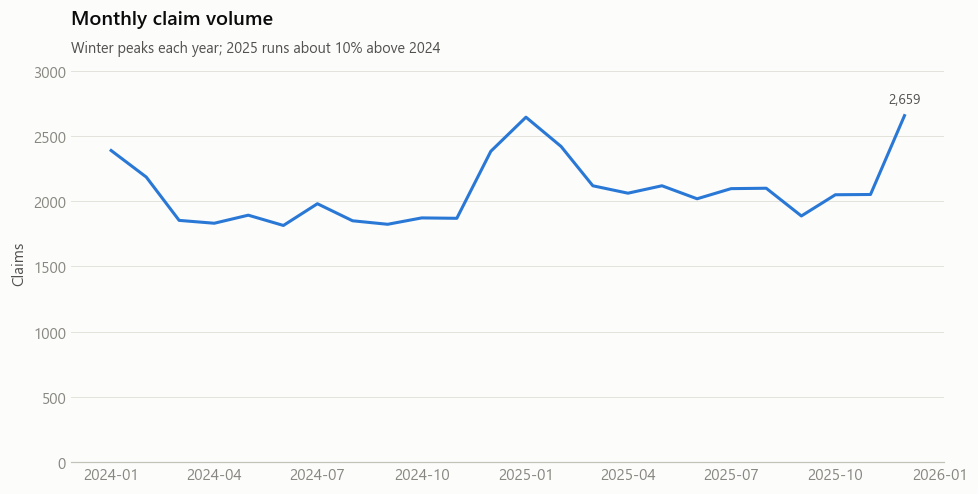

In [3]:
monthly = claims.groupby(claims["service_date"].dt.to_period("M")).agg(
    claims=("claim_id", "count"), paid=("paid_amount", "sum")).to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["claims"], color=vs.BLUE)
ax.set_title("Monthly claim volume")
vs.subtitle(ax, "Winter peaks each year; 2025 runs about 10% above 2024")
ax.set_ylim(0, monthly["claims"].max() * 1.15)
ax.set_ylabel("Claims")
peak = monthly["claims"].idxmax()
ax.annotate(f"{monthly.loc[peak, 'claims']:,}", (peak, monthly.loc[peak, "claims"]),
            textcoords="offset points", xytext=(0, 8), ha="center", color=vs.INK_2, fontsize=9)
vs.save(fig, "01_monthly_volume")
plt.show()

## 3. Denial rate trend by claim type

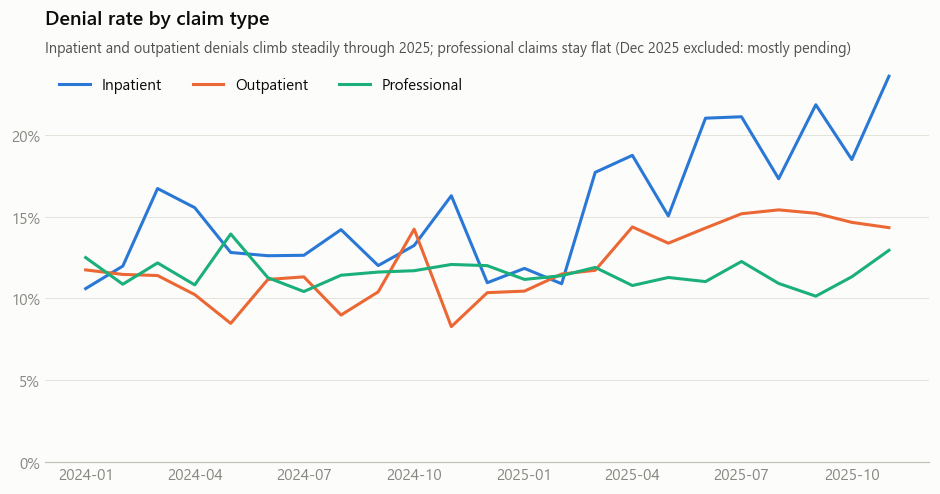

In [4]:
# December 2025 is excluded: most of its claims are still pending, so its rate is unreliable
recent = adjudicated[adjudicated["service_date"] < "2025-12-01"]
trend = (recent.groupby([recent["service_date"].dt.to_period("M"), "claim_type"])["is_denied"]
         .mean().unstack().to_timestamp())
order = ["Inpatient", "Outpatient", "Professional"]

fig, ax = plt.subplots()
for color, col in zip(vs.SERIES, order):
    ax.plot(trend.index, trend[col], color=color, label=col)
ax.set_title("Denial rate by claim type")
vs.subtitle(ax, "Inpatient and outpatient denials climb steadily through 2025; professional claims stay flat (Dec 2025 excluded: mostly pending)")
vs.pct(ax)
ax.set_ylim(0, None)
ax.legend(loc="upper left", ncol=3)
vs.save(fig, "02_denial_rate_trend")
plt.show()

## 4. Why are claims denied?

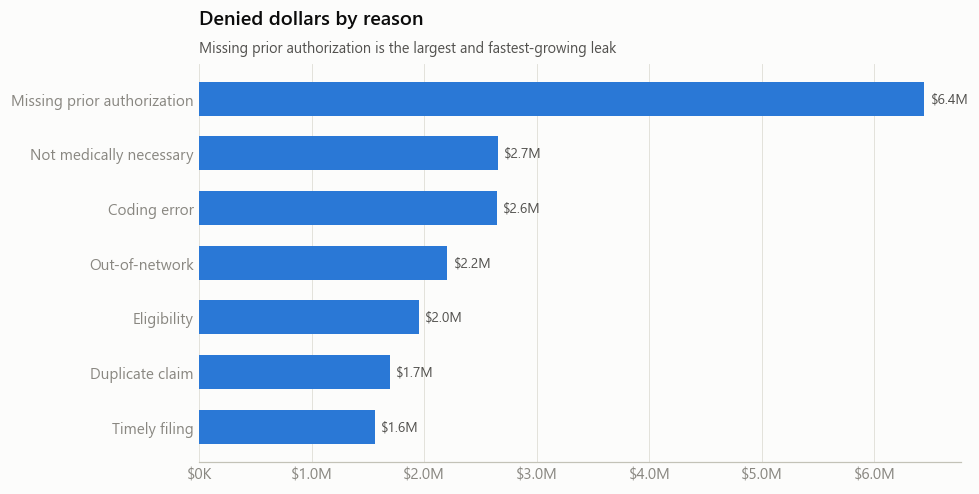

,claims,billed,share
denial_reason,,,
Missing prior authorization,1308,6445118.53,0.336
Not medically necessary,807,2653891.80,0.138
Coding error,933,2645929.32,0.138
Out-of-network,1130,2207421.37,0.115
Eligibility,586,1955542.80,0.102
Duplicate claim,466,1693492.22,0.088
Timely filing,542,1561555.33,0.081


In [5]:
denied = claims[claims["is_denied"] == 1]
reasons = denied.groupby("denial_reason").agg(claims=("claim_id", "count"),
                                              billed=("billed_amount", "sum")).sort_values("billed")

fig, ax = plt.subplots()
bars = ax.barh(reasons.index, reasons["billed"], color=vs.BLUE, height=0.62)
ax.bar_label(bars, labels=[f"${v/1e6:,.1f}M" for v in reasons["billed"]], padding=4, color=vs.INK_2, fontsize=9)
ax.set_title("Denied dollars by reason")
vs.subtitle(ax, "Missing prior authorization is the largest and fastest-growing leak")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
vs.money(ax, "x")
vs.save(fig, "03_denials_by_reason")
plt.show()
reasons.sort_values("billed", ascending=False).assign(share=lambda d: (d["billed"] / d["billed"].sum()).round(3))

In [6]:
prior_auth = (denied.assign(year=denied["service_date"].dt.year)
              .pivot_table(index="denial_reason", columns="year", values="claim_id", aggfunc="count"))
prior_auth["change_%"] = ((prior_auth[2025] / prior_auth[2024] - 1) * 100).round(1)
prior_auth.sort_values("change_%", ascending=False)

year,2024,2025,change_%
denial_reason,,,
Missing prior authorization,438,870,98.6
Out-of-network,565,565,0.0
Not medically necessary,406,401,-1.2
Coding error,480,453,-5.6
Eligibility,313,273,-12.8
Duplicate claim,251,215,-14.3
Timely filing,323,219,-32.2


## 5. Network status and plan type

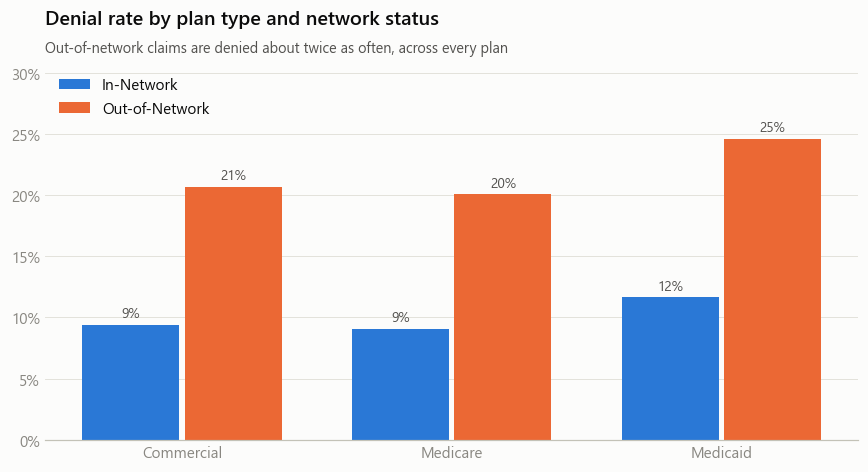

network_status,In-Network,Out-of-Network
plan_type,,
Commercial,9.4%,20.7%
Medicare,9.1%,20.1%
Medicaid,11.7%,24.6%


In [7]:
grid = adjudicated.pivot_table(index="plan_type", columns="network_status", values="is_denied", aggfunc="mean")
grid = grid.loc[["Commercial", "Medicare", "Medicaid"]]

fig, ax = plt.subplots(figsize=(8, 4.4))
x = range(len(grid))
w = 0.36
for i, (col, color) in enumerate(zip(["In-Network", "Out-of-Network"], [vs.BLUE, vs.ORANGE])):
    bars = ax.bar([p + (i - 0.5) * (w + 0.02) for p in x], grid[col], width=w, color=color, label=col)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in grid[col]], padding=3, color=vs.INK_2, fontsize=9)
ax.set_xticks(list(x), grid.index)
ax.set_title("Denial rate by plan type and network status")
vs.subtitle(ax, "Out-of-network claims are denied about twice as often, across every plan")
vs.pct(ax)
ax.legend(loc="upper left")
ax.set_ylim(0, grid.values.max() * 1.25)
vs.save(fig, "04_network_plan_denials")
plt.show()
grid.style.format("{:.1%}")

## 6. Provider outliers

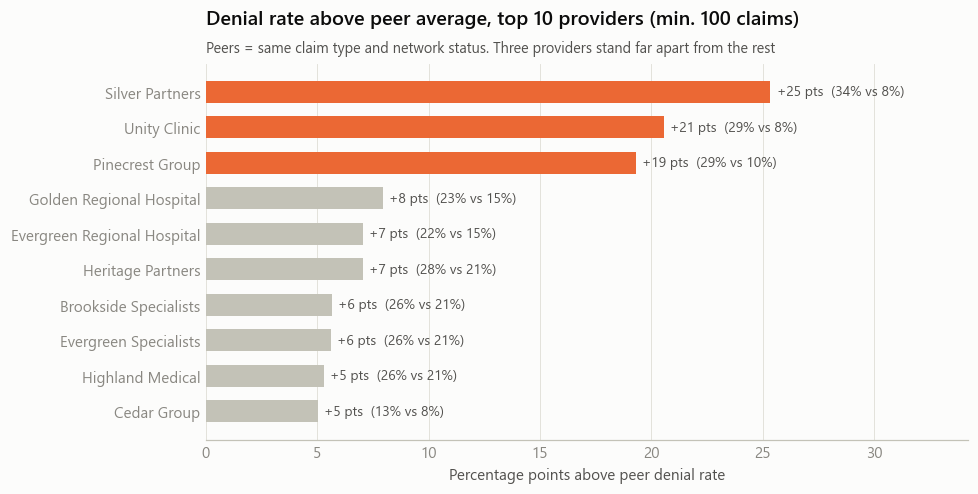

,provider_name,specialty,network_status,claims,denial_rate,excess_pts,denied_billed
provider_id,,,,,,,
PR0136,Silver Partners,Pediatrics,In-Network,178,0.337079,0.253450,10753.55
PR0135,Unity Clinic,Primary Care,In-Network,197,0.289340,0.205711,11933.60
PR0006,Pinecrest Group,Emergency Medicine,In-Network,171,0.292398,0.192912,114602.51
PR0164,Golden Regional Hospital,Hospital,In-Network,190,0.226316,0.079647,586600.10
PR0169,Evergreen Regional Hospital,Hospital,In-Network,198,0.217172,0.070503,729949.30
PR0045,Heritage Partners,Cardiology,Out-of-Network,183,0.278689,0.070455,66891.16
PR0092,Brookside Specialists,Pediatrics,Out-of-Network,185,0.264865,0.056631,11591.51
PR0228,Evergreen Specialists,Behavioral Health,Out-of-Network,193,0.264249,0.056015,15370.88
PR0246,Highland Medical,Primary Care,Out-of-Network,203,0.261084,0.052850,14558.18


In [8]:
prov = (adjudicated.groupby("provider_id")
        .agg(claims=("claim_id", "count"), denial_rate=("is_denied", "mean"),
             denied_billed=("billed_amount", lambda s: s[adjudicated.loc[s.index, "is_denied"] == 1].sum()))
        .query("claims >= 100")
        .join(providers.set_index("provider_id")[["provider_name", "specialty", "network_status"]]))
# compare each provider with peers of the same claim type and network status, so hospitals
# are not flagged just because inpatient claims are denied more often everywhere
peer_avg = adjudicated.groupby(["claim_type", "network_status"])["is_denied"].mean()
prov_type = adjudicated.groupby("provider_id")["claim_type"].first()
prov["expected_rate"] = [peer_avg[(prov_type[i], n)] for i, n in zip(prov.index, prov["network_status"])]
prov["excess_pts"] = prov["denial_rate"] - prov["expected_rate"]
top = prov.sort_values("excess_pts", ascending=False).head(10)

fig, ax = plt.subplots()
top_plot = top.iloc[::-1]
colors = [vs.ORANGE if e > 0.10 else vs.NEUTRAL for e in top_plot["excess_pts"]]
bars = ax.barh(top_plot["provider_name"], top_plot["excess_pts"] * 100, color=colors, height=0.62)
ax.bar_label(bars, labels=[f"+{e*100:.0f} pts  ({r:.0%} vs {x:.0%})" for e, r, x in
                           zip(top_plot["excess_pts"], top_plot["denial_rate"], top_plot["expected_rate"])],
             padding=4, color=vs.INK_2, fontsize=9)
ax.set_title("Denial rate above peer average, top 10 providers (min. 100 claims)")
vs.subtitle(ax, "Peers = same claim type and network status. Three providers stand far apart from the rest")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Percentage points above peer denial rate")
ax.set_xlim(0, top["excess_pts"].max() * 100 * 1.35)
vs.save(fig, "05_provider_outliers")
plt.show()
top[["provider_name", "specialty", "network_status", "claims", "denial_rate", "excess_pts", "denied_billed"]]

## 7. Cost by specialty

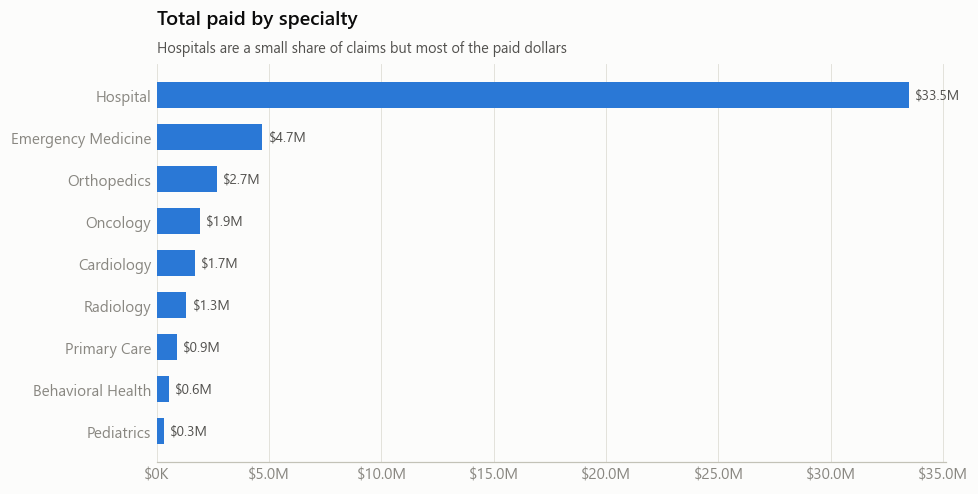

,paid,claims,avg_paid,share_of_paid
specialty,,,,
Hospital,33485019.75,6191,5408.660919,0.704
Emergency Medicine,4708403.33,6049,778.377142,0.099
Orthopedics,2675806.36,4504,594.095551,0.056
Oncology,1928701.21,1420,1358.240289,0.041
Cardiology,1691570.13,4179,404.778686,0.036
Radiology,1319023.92,5006,263.488598,0.028
Primary Care,882955.57,11758,75.094027,0.019
Behavioral Health,557474.55,6058,92.022871,0.012
Pediatrics,322997.46,4835,66.804025,0.007


In [9]:
spec = claims.groupby("specialty").agg(paid=("paid_amount", "sum"), claims=("claim_id", "count"),
                                       avg_paid=("paid_amount", "mean")).sort_values("paid")

fig, ax = plt.subplots()
bars = ax.barh(spec.index, spec["paid"], color=vs.BLUE, height=0.62)
ax.bar_label(bars, labels=[f"${v/1e6:,.1f}M" for v in spec["paid"]], padding=4, color=vs.INK_2, fontsize=9)
ax.set_title("Total paid by specialty")
vs.subtitle(ax, "Hospitals are a small share of claims but most of the paid dollars")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
vs.money(ax, "x")
vs.save(fig, "06_paid_by_specialty")
plt.show()
spec.sort_values("paid", ascending=False).assign(share_of_paid=lambda d: (d["paid"] / d["paid"].sum()).round(3))

## 8. Processing time

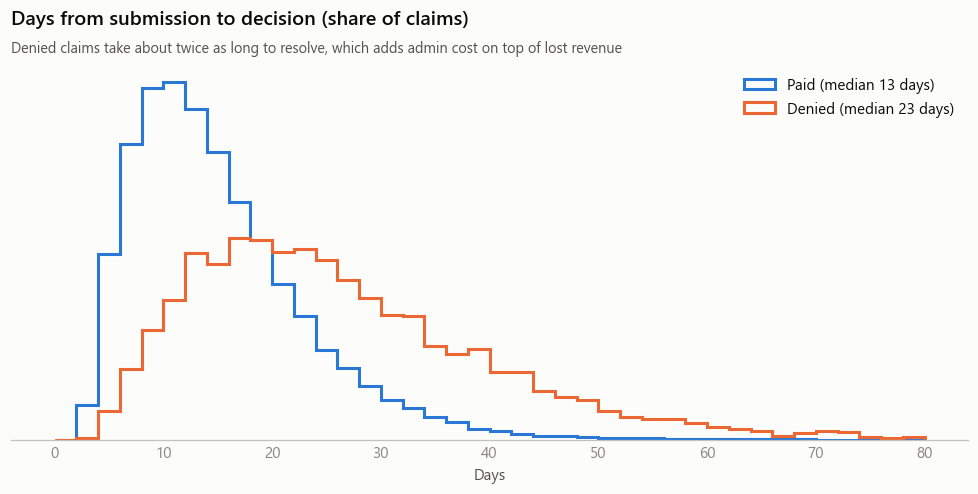

In [10]:
fig, ax = plt.subplots()
bins = range(0, 81, 2)
for status, color in [("Paid", vs.BLUE), ("Denied", vs.ORANGE)]:
    days = claims.loc[claims["claim_status"] == status, "days_to_process"]
    ax.hist(days, bins=bins, color=color, histtype="step", linewidth=2, density=True,
            label=f"{status} (median {days.median():.0f} days)")
ax.set_title("Days from submission to decision (share of claims)")
vs.subtitle(ax, "Denied claims take about twice as long to resolve, which adds admin cost on top of lost revenue")
ax.set_xlabel("Days"); ax.set_yticks([])
ax.legend()
vs.save(fig, "07_processing_time")
plt.show()

## 9. Findings and recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Missing prior authorization** is the #1 denial reason by dollars, and inpatient/outpatient denial rates rose month over month through 2025. | Add a prior-auth check at scheduling for inpatient and imaging services, then track the rate weekly. |
| 2 | **Out-of-network** claims are denied about 2x as often as in-network claims (20-25% vs 9-12%), across all plan types. | Steer referrals to in-network providers and target recruiting at high-volume out-of-network specialties. |
| 3 | **Three providers** run denial rates 19-26 points above their network peers, mostly from coding errors and duplicate claims. | Offer billing education or a claim-scrubber audit to the flagged providers. |
| 4 | **Timely-filing** denials are 100% preventable (the claim was submitted more than 90 days after service). | Alert when a claim is still unsubmitted 60 days after service. |
| 5 | Denied claims take about **2x longer** to resolve. | Every avoided denial also saves processing time. |

*Figures are computed from a synthetic dataset built for portfolio purposes.*